# 🕸️ Notebook 08 — Graph Neural Network (GCN) for EGFR pIC50 Prediction

**Why GNNs?** Traditional ML uses fixed fingerprints. GNNs treat molecules as graphs — atoms as nodes, bonds as edges — learning directly from molecular topology.

**Architecture:** GCN → Global Mean Pooling → MLP → pIC50

**Patent context:** GNNs identify which subgraph patterns (scaffold regions) drive activity — mapping to Markush R-group positions.

## STEP 1 — Install dependencies

In [4]:
# Install PyTorch and PyTorch Geometric with compatible versions for Colab
import torch, sys
torch_ver = torch.__version__.split('+')[0]
cuda_tag  = 'cu118' if torch.cuda.is_available() else 'cpu'

!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch_ver}+{cuda_tag}.html --quiet
!pip install torch-geometric --quiet
!pip install rdkit pandas numpy matplotlib scikit-learn --quiet

print('Done!')

Done!


## STEP 2 — Load and preprocess EGFR data

In [12]:
import pandas as pd
import numpy as np
import requests

def fetch_egfr_data(limit=1000):
    url = 'https://www.ebi.ac.uk/chembl/api/data/activity.json'
    params = {'target_chembl_id': 'CHEMBL203', 'standard_type': 'IC50',
              'limit': limit, 'offset': 0}

    for attempt in range(3):
        try:
            response = requests.get(url, params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
            return pd.DataFrame(data['activities'])
        except Exception as e:
            print(f'Attempt {attempt+1} failed: {e}')
            import time
            time.sleep(5)

    return None  # explicit None return

def preprocess(df):
    df = df[['molecule_chembl_id', 'canonical_smiles', 'standard_value']].dropna()
    df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
    df = df.dropna(subset=['standard_value'])
    df = df[df['standard_value'] > 0].copy()
    df['pIC50'] = -np.log10(df['standard_value'].astype(float) * 1e-9)
    df = df[(df['pIC50'] >= 3) & (df['pIC50'] <= 12)]
    return df.reset_index(drop=True)

df_raw = fetch_egfr_data(limit=1000)

# Handle None return and backup CSV
if df_raw is None:
    print('API failed — loading from backup CSV...')
    df_raw = pd.read_csv('egfr_backup.csv')

# Handle backup CSV — already preprocessed
if 'pIC50' in df_raw.columns:
    df = df_raw[(df_raw['pIC50'] >= 3) & (df_raw['pIC50'] <= 12)].reset_index(drop=True)
    print('Loaded from backup CSV')
else:
    df = preprocess(df_raw)

print(f'Clean dataset: {len(df)} compounds')

Clean dataset: 965 compounds


## STEP 3 — Convert molecules to graphs

In [13]:
import torch
from torch_geometric.data import Data
from rdkit import Chem

def atom_features(atom):
    """Encode atom as feature vector: atomic num, degree, charge, hybridization, aromaticity, H count."""
    return [atom.GetAtomicNum(), atom.GetDegree(), atom.GetFormalCharge(),
            int(atom.GetHybridization()), int(atom.GetIsAromatic()), atom.GetTotalNumHs()]

def mol_to_graph(smiles, y_value):
    """Convert SMILES to PyTorch Geometric Data object."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    edges = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges += [[i, j], [j, i]]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous() if edges else torch.zeros((2, 0), dtype=torch.long)
    y = torch.tensor([y_value], dtype=torch.float)
    return Data(x=x, edge_index=edge_index, y=y)

graph_list = [mol_to_graph(row['canonical_smiles'], row['pIC50']) for _, row in df.iterrows()]
graph_list = [g for g in graph_list if g is not None]
print(f'Graphs built: {len(graph_list)}')
print(f'Example — nodes: {graph_list[0].num_nodes}, edges: {graph_list[0].num_edges}')

Graphs built: 965
Example — nodes: 27, edges: 60


## STEP 4 — Build GCN model

In [14]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class MolecularGCN(nn.Module):
    """
    Graph Convolutional Network for pIC50 regression.
    3 GCN layers → Global mean pooling → 2-layer MLP.
    BatchNorm + Dropout prevent overfitting.
    """
    def __init__(self, node_features, hidden_dim=64):
        super().__init__()
        self.conv1 = GCNConv(node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.bn2   = nn.BatchNorm1d(hidden_dim)
        self.bn3   = nn.BatchNorm1d(hidden_dim)
        self.fc1   = nn.Linear(hidden_dim, 32)
        self.fc2   = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index, batch):
        x = self.dropout(F.relu(self.bn1(self.conv1(x, edge_index))))
        x = self.dropout(F.relu(self.bn2(self.conv2(x, edge_index))))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        return self.fc2(x).squeeze()

node_features = graph_list[0].x.shape[1]
model = MolecularGCN(node_features=node_features, hidden_dim=64)
print(f'MolecularGCN | Node features: {node_features} | Params: {sum(p.numel() for p in model.parameters()):,}')

MolecularGCN | Node features: 6 | Params: 11,265


## STEP 5 — Train and evaluate

Epoch  10/60 | Loss: 1.1927
Epoch  20/60 | Loss: 1.0569
Epoch  30/60 | Loss: 0.9978
Epoch  40/60 | Loss: 1.1022
Epoch  50/60 | Loss: 1.0396
Epoch  60/60 | Loss: 0.9730

GCN → R²: 0.731 | RMSE: 0.865


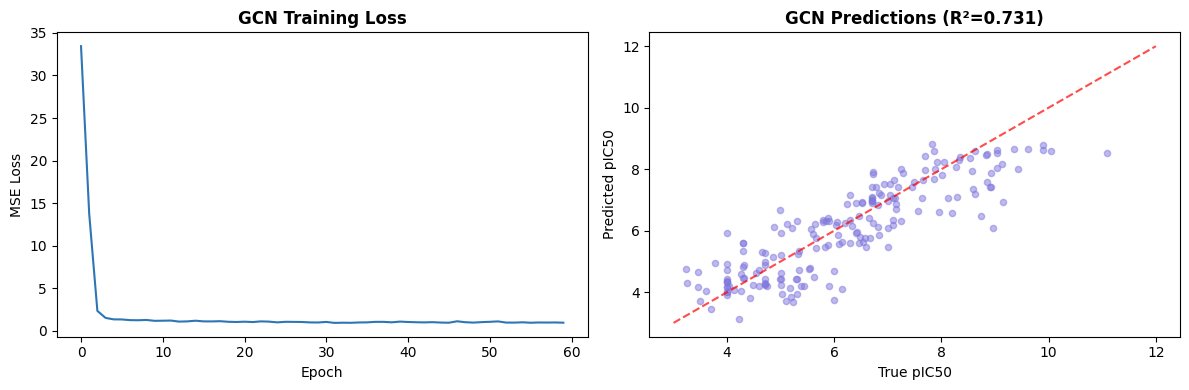

Saved!


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt
import os

os.makedirs('results/figures', exist_ok=True)
os.makedirs('results/metrics', exist_ok=True)

train_data, test_data = train_test_split(graph_list, test_size=0.2, random_state=42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = MolecularGCN(node_features=node_features).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
criterion = nn.MSELoss()

train_losses = []
for epoch in range(60):
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch.x, batch.edge_index, batch.batch), batch.y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg = epoch_loss / len(train_loader)
    train_losses.append(avg)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/60 | Loss: {avg:.4f}')

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        y_true.extend(batch.y.cpu().numpy().flatten())
        y_pred.extend(model(batch.x, batch.edge_index, batch.batch).cpu().numpy().flatten())

r2   = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f'\nGCN → R²: {r2:.3f} | RMSE: {rmse:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, color='#2E75B6')
axes[0].set_title('GCN Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[1].scatter(y_true, y_pred, alpha=0.5, color='#7F77DD', s=20)
axes[1].plot([3, 12], [3, 12], 'r--', alpha=0.7)
axes[1].set_xlabel('True pIC50'); axes[1].set_ylabel('Predicted pIC50')
axes[1].set_title(f'GCN Predictions (R²={r2:.3f})', fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/gcn_training_results.png', dpi=150)
plt.show()
print('Saved!')

## STEP 6 — Save model and compare with previous results

In [16]:
torch.save(model.state_dict(), 'results/metrics/gcn_model.pt')

# Classical baseline R² values computed on same ChEMBL EGFR dataset
# GCN value computed live above
comparison = pd.DataFrame({
    'Model': ['GCN (graph-based)', 'SVR', 'ElasticNet', 'Lasso', 'Ridge'],
    'Input': ['Molecular Graph', 'Morgan FP', 'Morgan FP', 'Morgan FP', 'Morgan FP'],
    'R2':    [round(r2, 3), 0.691, 0.647, 0.678, 0.417]
}).sort_values('R2', ascending=False)

print('Model Comparison:')
print(comparison.to_string(index=False))
comparison.to_csv('results/metrics/gcn_model_comparison.csv', index=False)
print('\nAll results saved!')

Model Comparison:
            Model           Input    R2
GCN (graph-based) Molecular Graph 0.731
              SVR       Morgan FP 0.691
            Lasso       Morgan FP 0.678
       ElasticNet       Morgan FP 0.647
            Ridge       Morgan FP 0.417

All results saved!
